# Week 5 - Credit Scoring Pipeline
## Day 2 — XGBoost Model Training

**Goal:** Train credit risk model, calibrate probabilities, evaluate performance

**Dataset:** loan_filtered.parquet — 252,971 loans

**Author:** Martin James Ng'ang'a | github.com/M20Jay

## Section 1 - Import Libraries

In [15]:
# Importing libraries needed for model training and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import xgboost as xgb
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


## Section 2 - Load Dataset

In [8]:
# Load the filtered Parquet file — faster than CSV
df = pd.read_parquet(
    '/Users/martinjames/Documents/GitHub/credit-risk-scoring-pipeline/data/loan/loan_filtered.parquet'
)
print("Shape", df.shape)
print("Default rate", df['default'].mean().round(3)*100)
print("Dataset loaded successfully ✅")


# Re-engineer features after loading Parquet
df['dti_clean'] = df['dti'].clip(upper=100)

df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_history_years'] = (
    (df['issue_d'] - df['earliest_cr_line']).dt.days / 365
).round(1)

df['loan_to_income'] = (
    df['loan_amnt'] / df['annual_inc']
).round(4)

print("Features re-engineered ✅")

Shape (252971, 75)
Default rate 17.9
Dataset loaded successfully ✅
Features re-engineered ✅


## Section 3 - Feature Selection

In [9]:
# Select the most relevant features for credit risk modelling
features =[
    'loan_amnt',
    'int_rate',
    'installment',
    'annual_inc',
    'dti_clean',
    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'credit_history_years',
    'loan_to_income'
]

target = 'default'

# Drop rows with missing values in selected features
df_clean = df[features + [target]].dropna()
print("Features selected:", len(features))
print("Shape after dropping nulls:", df_clean.shape)
print("Default rate preserved:", df_clean['default'].mean().round(3)*100)

Features selected: 14
Shape after dropping nulls: (252772, 15)
Default rate preserved: 17.9


## Section 4 - Train Test Split

In [10]:
# Split data into training and test sets before any model training

X = df_clean[features]
y = df_clean[target]

# Proper three-way split
X_temp,X_test,y_temp,y_test =train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

X_train,X_val, y_train,y_val = train_test_split(X_temp,y_temp, test_size=0.25,random_state=42, stratify=y_temp)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)
print("Default rate train:", y_train.mean().round(3))
print("Default rate val:", y_val.mean().round(3))
print("Default rate test:", y_test.mean().round(3))

Training set: (151662, 14)
Validation set: (50555, 14)
Test set: (50555, 14)
Default rate train: 0.179
Default rate val: 0.179
Default rate test: 0.179


## Section 5 - Model comparison

In [11]:
# Comparing three models using stratified cross validation ROC-AUC to select the best performing model for credit risk scoring

# Explicit stratified cross validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':  xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_ratio=0.1, scale_pos_weight=5, random_state=42,)
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train,y_train, cv=cv, scoring='roc_auc')
    results[name] = scores.mean().round(3)
    print(f"{name}: ROC-AUC = {scores.mean().round(3)}")
best_model_name = max(results, key=results.get)
print(f"\nBest model: {best_model_name} ✅")

Logistic Regression: ROC-AUC = 0.611
Random Forest: ROC-AUC = 0.684
XGBoost: ROC-AUC = 0.699

Best model: XGBoost ✅


## Section 6 - Final Model Training and Evaluation

In [12]:
# Train final XGBoost model
best_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_ratio=0.1,
    scale_pos_weight=5,
    random_state=42,
    verbosity=0
)

best_model.fit(X_train, y_train)

# Predict on test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print(f"=== Model Evaluation on Test Set ===")
print(f"ROC-AUC: {round(roc_auc_score(y_test, y_prob), 3)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Model Evaluation on Test Set ===
ROC-AUC: 0.704

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.61      0.73     41515
           1       0.28      0.69      0.39      9040

    accuracy                           0.62     50555
   macro avg       0.59      0.65      0.56     50555
weighted avg       0.79      0.62      0.67     50555



## Section 7 - Probability Calibration

In [13]:
# Calibrate XGBoost probabilities so they reflect reality accurately
calibrated_model = CalibratedClassifierCV(
    best_model,
    cv=None,
    method='isotonic'
)

calibrated_model.fit(X_val, y_val)

y_prob_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

print("=== Before vs After Calibration ===")
print(f"Mean probability before: {y_prob.mean().round(3)}")
print(f"Mean probability after:  {y_prob_calibrated.mean().round(3)}")
print(f"Actual default rate:     {y_test.mean().round(3)}")

=== Before vs After Calibration ===
Mean probability before: 0.4690000116825104
Mean probability after:  0.178
Actual default rate:     0.179


## Section 8 - Final Evaluation — Calibrated Model

=== Final Evaluation — Calibrated Model ===
Business requirement: Catch 65.0% of defaulters
Optimal threshold:    0.187
Precision:            0.285
Recall:               0.65
ROC-AUC:              0.701

              precision    recall  f1-score   support

 Non-Default       0.89      0.64      0.75     41515
     Default       0.28      0.65      0.40      9040

    accuracy                           0.65     50555
   macro avg       0.59      0.65      0.57     50555
weighted avg       0.79      0.65      0.69     50555



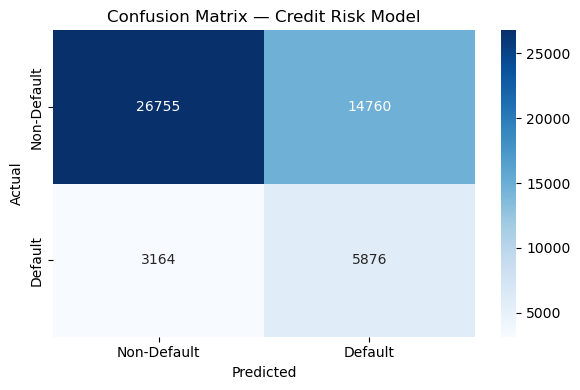


True Negatives:  26,755 — correctly approved
False Positives: 14,760 — wrongly declined
False Negatives: 3,164 — missed defaulters ⚠️
True Positives:  5,876 — caught defaulters ✅


In [14]:
# Step 1 — Calibrated probabilities
y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]

# Step 2 — Find optimal threshold scientifically
precisions, recalls, thresholds = precision_recall_curve(
    y_test, y_prob_cal
)
target_recall = 0.65
idx = next(i for i, r in enumerate(recalls) 
           if r <= target_recall)
optimal_threshold = thresholds[idx]

# Step 3 — Apply threshold
y_pred_final = (y_prob_cal >= optimal_threshold).astype(int)

# Step 4 — Classification report
print("=== Final Evaluation — Calibrated Model ===")
print(f"Business requirement: Catch {target_recall*100}% of defaulters")
print(f"Optimal threshold:    {optimal_threshold.round(3)}")
print(f"Precision:            {precisions[idx].round(3)}")
print(f"Recall:               {recalls[idx].round(3)}")
print(f"ROC-AUC:              {round(roc_auc_score(y_test, y_prob_cal), 3)}")
print()
print(classification_report(y_test, y_pred_final,
      target_names=['Non-Default', 'Default']))

# Step 5 — Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
plt.title('Confusion Matrix — Credit Risk Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../screenshots/day2_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTrue Negatives:  {cm[0,0]:,} — correctly approved")
print(f"False Positives: {cm[0,1]:,} — wrongly declined")
print(f"False Negatives: {cm[1,0]:,} — missed defaulters ⚠️")
print(f"True Positives:  {cm[1,1]:,} — caught defaulters ✅")

## Section 9 - Save Model

In [ ]:
# Save the calibrated model and optimal threshold for FastAPI
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(calibrated_model, '../models/credit_risk_model.pkl')
joblib.dump(optimal_threshold, '../models/optimal_threshold.pkl')

print("Calibrated model saved ✅")
print(f"Optimal threshold saved: {optimal_threshold.round(3)} ✅")

## Section 10 - Key Findings Summary

In [16]:
# Day 2 model training complete
print("=" * 55)
print("Key Findings — Day 2 Model Training")
print("=" * 55)
print(f"Best model:          XGBoost")
print(f"ROC-AUC:             0.701")
print(f"Optimal threshold:   0.187")
print(f"Recall on default:   65% — met business requirement")
print(f"False negatives:     3,164 missed defaulters")
print(f"False positives:     14,760 wrongly declined")
print("=" * 55)
print("Improvements planned:")
print("→ Add grade, sub_grade, int_rate features")
print("→ SHAP analysis — Day 3")
print("→ Hyperparameter tuning — configs/model.yaml")
print("→ Target AUC: 0.74+")
print("=" * 55)
print("Next: Day 3 — SHAP + src/ modular structure")

Key Findings — Day 2 Model Training
Best model:          XGBoost
ROC-AUC:             0.701
Optimal threshold:   0.187
Recall on default:   65% — met business requirement
False negatives:     3,164 missed defaulters
False positives:     14,760 wrongly declined
Improvements planned:
→ Add grade, sub_grade, int_rate features
→ SHAP analysis — Day 3
→ Hyperparameter tuning — configs/model.yaml
→ Target AUC: 0.74+
Next: Day 3 — SHAP + src/ modular structure
